# Matching

In [1]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt


RF-Track, version 2.6.3

Copyright (C) 2016-2026 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.11



[RF-Track] Could not check for updates.


## Bunch parameters

In [2]:
# Bunch parameters
mass = rft.electronmass # MeV/c^2
charge = -1 # single-particle charge, in units of e
population = 1*rft.nC # number of real particles per bunch
Pc = 5 # reference momentum, MeV/c
P_Q = Pc / charge # MV/c, reference rigidity

## FODO cell parameters

In [3]:
# FODO cell parameters
Lcell = 2 # m
Lquad = 0.2 # m
Ldrift = Lcell/2 - Lquad # m

mu = np.deg2rad(90) # deg
k1L = np.sin(mu/2) / (Lcell/4) # 1/m

strength = k1L * P_Q # MeV/m

In [4]:
print(strength)

-7.071067811865475


## Let's define the elements

In [5]:
# Half a focusing quadrupole

Qf = rft.Quadrupole(Lquad/2, strength/2)
Qf.set_tt_nsteps(10)

# A full, defocusing, quadrupole
QD = rft.Quadrupole(Lquad, -strength)
QD.set_tt_nsteps(20)

# The Drift
Dr = rft.Drift(Ldrift)
Dr.set_tt_nsteps(100)

# Let's define a lattice with 10 FODO cells

In [6]:
# Define the FODO cell
FODO = rft.Lattice()
FODO.append(Qf)
FODO.append(Dr)
FODO.append(QD)
FODO.append(Dr)
FODO.append(Qf)

# Create the full lattice by repeating the FODO cell 10 times
L = rft.Lattice()
for _ in range(10):
    L.append(FODO)

In [7]:
L.get_length() # return meters

20.0

In [8]:
L.size()

10

In [9]:
L[0][0].get_length()

0.1

In [10]:
L[0].size()

5

# ...and a bunch

In [11]:
# Define Twiss parameters
Twiss = rft.Bunch6d_twiss()
Twiss.emitt_x = 0.001 # mm.mrad, normalized emittances
Twiss.emitt_y = 0.001 # mm.mrad
Twiss.alpha_x = 0.0
Twiss.alpha_y = 0.0
Twiss.beta_x = Lcell * (1 + np.sin(mu/2)) / np.sin(mu) # m
Twiss.beta_y = Lcell * (1 - np.sin(mu/2)) / np.sin(mu) # m

# Create the bunch
B0 = rft.Bunch6d_QR (mass, population, charge, Pc, Twiss, 10000)

In [12]:
print(Twiss.beta_x)
print(Twiss.beta_y)

3.414213562373095
0.5857864376269051


# Then, we can perform tracking

In [13]:
B1 = L.track(B0)

We can inquire the lattice to find out, for example, the Twiss parameters and the emittance

In [14]:
T = L.get_transport_table('%S %beta_x %beta_y %emitt_x %emitt_y %sigma_x %sigma_y');

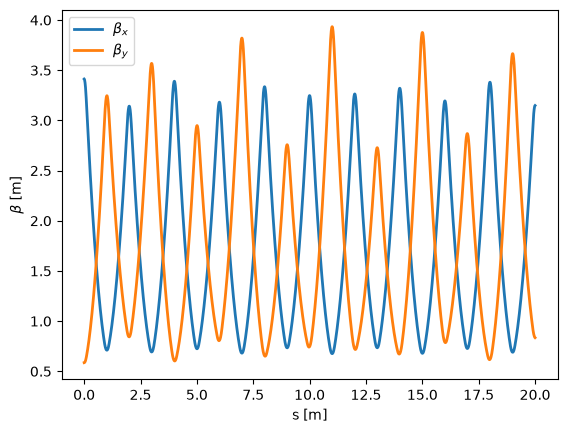

In [15]:
plt.plot(T[:,0], T[:,1], linewidth=2, label=r'$\beta_x$')
plt.plot(T[:,0], T[:,2], linewidth=2, label=r'$\beta_y$')
plt.legend()
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
plt.show()

# Now we can match the Twiss parameters to be periodic
## Start with defining a merit function
This function returns zero when the initial and the final beta have the same value, while alpha are opposite:
\begin{align*}
\chi^{2}= & \left(\beta_{x,\text{ final}}-\beta_{x,\text{ initial}}\right)^{2}+\cdots\\
 & \left(\beta_{y,\text{ final}}-\beta_{y,\text{ initial}}\right)^{2}+\cdots\\
 & \left(\alpha_{x,\text{ final}}+\alpha_{x,\text{ initial}}\right)^{2}+\cdots\\
 & \left(\alpha_{y,\text{ final}}+\alpha_{y,\text{ initial}}\right)^{2}
\end{align*}

In [16]:
from scipy.optimize import minimize

def match_Twiss(betas, FODO):

    # Create a bunch with initial beta_x and beta_y from 'betas'
    # Define Twiss parameters
    Twiss = rft.Bunch6d_twiss()
    Twiss.emitt_x = 0.001 # mm.mrad, normalized emittances
    Twiss.emitt_y = 0.001 # mm.mrad
    Twiss.beta_x = betas[0] # m
    Twiss.beta_y = betas[1] # m
    
    # Create the bunch
    B0 = rft.Bunch6d_QR (mass, population, charge, Pc, Twiss, 10000)
    
    # Perform tracking
    B1 = FODO.track(B0)
    I1 = B1.get_info()

    # Compute the merit function
    M = ((I1.beta_x - betas[0]) ** 2 +
         (I1.beta_y - betas[1]) ** 2 +
         (I1.alpha_x + 0.0) ** 2 + # final alpha = -initial alpha
         (I1.alpha_y + 0.0) ** 2)

    print(betas[0], betas[1], M)
    return M

Now, call the minization function ```minimize (func, bounds=[(xmin, xmax), ... ])```

In [17]:
# Define the merit function
merit = lambda S: match_Twiss(S, FODO)

# Optimization settings and execution
initial_guess = [ Twiss.beta_x, Twiss.beta_y ]
result = minimize(merit, initial_guess, bounds=[(0,10),(0, 10)])

beta_x = result.x[0]
beta_y = result.x[1]

3.414213562373095 0.5857864376269051 0.14286500653372863
3.414213572373095 0.5857864376269051 0.1428650167931345
3.414213562373095 0.5857864476269051 0.14286499368590336
2.3882729680982395 1.8705689587597505 6.821583086758703
2.3882729780982395 1.8705689587597505 6.821582970208209
2.3882729680982395 1.8705689687597504 6.821583123411983
3.2625306738187327 0.7757384924116447 0.01869853916324546
3.2625306838187327 0.7757384924116447 0.01869853835936542
3.2625306738187327 0.7757385024116448 0.018698544099955302
3.2752173801783484 0.724046595000304 0.0014510655633193188
3.2752173901783483 0.724046595000304 0.0014510657432187696
3.2752173801783484 0.724046605000304 0.001451067035453668
3.2714691811868235 0.7016766141174242 5.131640542190321e-05
3.2714691911868234 0.7016766141174242 5.131629586233461e-05
3.2714691811868235 0.7016766241174243 5.131614606580575e-05
3.272934618177481 0.7050195479827669 1.9629940573254483e-06
3.272934628177481 0.7050195479827669 1.9629977861425416e-06
3.272934618

Let's create a beam with the matched beta functions

In [18]:
Twiss.beta_x = beta_x # m
Twiss.beta_y = beta_y # m

# Create the bunch
B0 = rft.Bunch6d_QR (mass, population, charge, Pc, Twiss, 10000)

In [19]:
B1 = L.track(B0)

In [20]:
T = L.get_transport_table('%S %beta_x %beta_y %emitt_x %emitt_y %sigma_x %sigma_y')

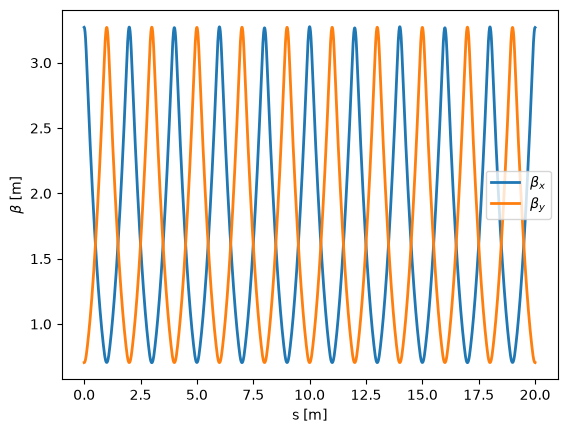

In [21]:
plt.plot(T[:,0], T[:,1], linewidth=2, label=r'$\beta_x$')
plt.plot(T[:,0], T[:,2], linewidth=2, label=r'$\beta_y$')
plt.legend()
plt.xlabel('s [m]')
plt.ylabel(r'$\beta$ [m]')
plt.show()

# Exercises

## Exercise 1 — Explore optimizer sensitivity

Repeat the matching from several different initial guesses and, if useful, with different bounds. Record whether each case converges, the final merit value, and whether it finds the same matched beta functions. Identify any solutions that are numerically converged but physically unreasonable.

Finally, add a penalty to the merit function for excessive beta functions, for example $\lambda(\beta_x^2+\beta_y^2)$, and investigate how changing $\lambda$ alters the compromise between periodicity and beam size.

In [ ]:
# Your solution
initial_betas = np.array([
    Lcell * (1 + np.sin(mu/2)) / np.sin(mu),
    Lcell * (1 - np.sin(mu/2)) / np.sin(mu),
])

initial_merit = match_Twiss(initial_betas, FODO)
matched_betas = result.x
matched_merit = match_Twiss(matched_betas, FODO)